<a href="https://colab.research.google.com/github/MhiyaJ/My-GIS-Stuff/blob/main/***School%20District%20Merge%20(ps01).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
%%capture
#!pip install geopandas #==1.0.1
#!pip install mapclassify #sometimes have to install library which you get from https://pypi.org/

In [115]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [116]:
#!python --version
gpd.__version__

'1.1.4'

**Hypothesis**: Limited access to affordable after-school programs contributes to increased social disengagement and delinquent behavior among students living in urban areas.

**Project Description:** Identifying the availability and accessibility of after school programs in low income areas and examining their relationship to youth social disengagement and delinquent behaviors.  

*Variables:* After school programs, economically disadvantaged youth population, delinquent/disengaged behavior, household income

Unified School Districts in NJ - includes and operates primary, secondary and high school as one district

Census data used to create boundaries for unified school districts.

NJ Office of GIS used Census data to establish unified school district boundaries in two areas, on and near military bases, were edited to reflect special arrangements made for students residing in base housing.

NJDOE used set of grades, based on financial responsibility, to assign the data for each child to exactly one school district, except for districts covering Joint Base McGuire-Dix-Lakehurst in Burlington County.

In [117]:
#NJ Office of GIS (Jan. 14, 2022), School Districts - Unified for NJ, 3424
#https://njogis-newjersey.opendata.arcgis.com/datasets/newjersey::school-districts-unified-for-nj-3424/about)
#unified school district shown in mp below was made with municipalities in mind
! wget -q -O nj-schools.zip https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/tl_2025_34_unsd.zip

zip_ref = zipfile.ZipFile('nj-schools.zip', 'r'); zip_ref.extractall(); zip_ref.close()

njSch=gpd.read_file('tl_2025_34_unsd.shp') #labeled shapefile njSch

<Axes: >

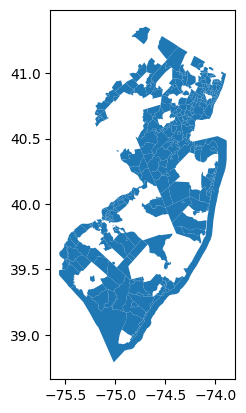

In [118]:
njSch.plot()

In [119]:
len(njSch)

342

In [120]:
njSch.dtypes #School District Headings

,0
STATEFP,object
UNSDLEA,object
GEOID,object
GEOIDFQ,object
NAME,object
LSAD,object
LOGRADE,object
HIGRADE,object
MTFCC,object
SDTYP,object


In [121]:
njSch

,STATEFP,UNSDLEA,GEOID,GEOIDFQ,NAME,LSAD,LOGRADE,HIGRADE,MTFCC,SDTYP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,34,02640,3402640,9700000US3402640,Camden City School District,00,KG,12,G5420,None,E,23099012,3780178,+39.9367868,-075.1066438,"POLYGON ((-75.13629 39.94659, -75.13617 39.947..."
1,34,12990,3412990,9700000US3412990,Pine Hill Borough School District,00,KG,12,G5420,None,E,12600833,148584,+39.7857197,-074.9808158,"POLYGON ((-75.02369 39.80423, -75.02028 39.804..."
2,34,08640,3408640,9700000US3408640,Lindenwold Borough School District,00,KG,12,G5420,None,E,10106242,108551,+39.8188320,-074.9899655,"POLYGON ((-75.02791 39.82128, -75.02787 39.821..."
3,34,06360,3406360,9700000US3406360,Haddon Township School District,00,KG,12,G5420,None,E,6972793,330210,+39.9062159,-075.0629510,"MULTIPOLYGON (((-75.07778 39.90316, -75.07541 ..."
4,34,10560,3410560,9700000US3410560,Montclair Town School District,00,KG,12,G5420,None,E,16156125,17325,+40.8249977,-074.2108562,"POLYGON ((-74.23763 40.80399, -74.23752 40.804..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,34,09480,3409480,9700000US3409480,Mannington Township School District,00,KG,12,G5420,None,E,87756328,10414613,+39.6232487,-075.4146621,"POLYGON ((-75.49097 39.65361, -75.49091 39.653..."
338,34,14280,3414280,9700000US3414280,Roselle Borough School District,00,KG,12,G5420,None,E,6824647,32524,+40.6522106,-074.2601578,"POLYGON ((-74.28325 40.65641, -74.28334 40.656..."
339,34,14310,3414310,9700000US3414310,Roselle Park Borough School District,00,KG,12,G5420,None,E,3171452,0,+40.6653092,-074.2665583,"POLYGON ((-74.28536 40.66526, -74.28515 40.665..."
340,34,15630,3415630,9700000US3415630,Springfield Township School District,00,KG,12,G5420,E,E,13356277,42636,+40.6979658,-074.3344355,"POLYGON ((-74.35784 40.69996, -74.35702 40.700..."


In [122]:
DisXls=pd.read_excel ('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Economically%20Disadvantage%20Youth%202024%20-%202025.xlsx', header = 3)

In [123]:
len(DisXls)

41

In [124]:
DisXls.dtypes

,0
CountyCode,int64
CountyName,object
DistrictCode,int64
DistrictName,object
SchoolYear,object
Female,object
Male,object
Non-Binary/Undesignated Gender,object
Economically Disadvantaged Students,object
Students with Disabilities,object


In [125]:
DisXls1=DisXls [['CountyName','DistrictName','Economically Disadvantaged Students']].copy()
DisXls1.rename(columns={'DistrictName' : 'NAME'}, inplace=True)
DisXls1

,CountyName,NAME,Economically Disadvantaged Students
0,Camden,Audubon Public School District,24.5%
1,Camden,Barrington School District,34.1%
2,Camden,Bellmawr Public School District,57.8%
3,Camden,Berlin Borough School District,25.2%
4,Camden,Berlin Township School District,53.3%
5,Camden,Black Horse Pike Regional School District,44.9%
6,Camden,Brooklawn Public School District,70.7%
7,Camden,Camden City School District,88.5%
8,Camden,Camden County Technical School District,56.1%
9,Camden,Cherry Hill School District,23.2%


In [126]:
njSch[['NAME','geometry']]
DisXls1['c']=DisXls1.NAME.str.strip()
njSch['c']=njSch.NAME.str.strip()

,NAME,geometry
0,Camden City School District,"POLYGON ((-75.13629 39.94659, -75.13617 39.947..."
1,Pine Hill Borough School District,"POLYGON ((-75.02369 39.80423, -75.02028 39.804..."
2,Lindenwold Borough School District,"POLYGON ((-75.02791 39.82128, -75.02787 39.821..."
3,Haddon Township School District,"MULTIPOLYGON (((-75.07778 39.90316, -75.07541 ..."
4,Montclair Town School District,"POLYGON ((-74.23763 40.80399, -74.23752 40.804..."
...,...,...
337,Mannington Township School District,"POLYGON ((-75.49097 39.65361, -75.49091 39.653..."
338,Roselle Borough School District,"POLYGON ((-74.28325 40.65641, -74.28334 40.656..."
339,Roselle Park Borough School District,"POLYGON ((-74.28536 40.66526, -74.28515 40.665..."
340,Springfield Township School District,"POLYGON ((-74.35784 40.69996, -74.35702 40.700..."


In [133]:
#code from Gemini to make all upper case for merging
DisXls1['NAME'] = DisXls1['NAME'].str.upper()
njSch['NAME'] = njSch['NAME'].str.upper()
njSch['first_two_words_NAME'] = njSch['NAME'].str.split().str[0]

In [134]:
#code from Gemini to match only the first word which is the name of the school and municipality
DisXls1['first_two_words_NAME'] = DisXls1['NAME'].str.split().str[0]

In [129]:
DisXls1[['NAME','Economically Disadvantaged Students']]

,NAME,Economically Disadvantaged Students
0,AUDUBON PUBLIC SCHOOL DISTRICT,24.5%
1,BARRINGTON SCHOOL DISTRICT,34.1%
2,BELLMAWR PUBLIC SCHOOL DISTRICT,57.8%
3,BERLIN BOROUGH SCHOOL DISTRICT,25.2%
4,BERLIN TOWNSHIP SCHOOL DISTRICT,53.3%
5,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,44.9%
6,BROOKLAWN PUBLIC SCHOOL DISTRICT,70.7%
7,CAMDEN CITY SCHOOL DISTRICT,88.5%
8,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,56.1%
9,CHERRY HILL SCHOOL DISTRICT,23.2%


In [138]:
split_njSch = njSch['NAME'].str.split()
njSch['first_two_words_NAME'] = split_njSch.str[0]
split_disXls1 = DisXls1['NAME'].str.split()
DisXls1['first_two_words_NAME'] = split_disXls1.str[0]

a1 = pd.merge(njSch, DisXls1, left_on=['first_two_words_NAME'], right_on=['first_two_words_NAME'], how='outer', indicator=True)
a1

,STATEFP,UNSDLEA,GEOID,GEOIDFQ,NAME_x,LSAD,LOGRADE,HIGRADE,MTFCC,SDTYP,...,INTPTLAT,INTPTLON,geometry,c_x,first_two_words_NAME,CountyName,NAME_y,Economically Disadvantaged Students,c_y,_merge
0,34,00660,3400660,9700000US3400660,ABSECON CITY SCHOOL DISTRICT,00,KG,12,G5420,None,...,+39.4235629,-074.4930249,"POLYGON ((-74.53123 39.42643, -74.5304 39.4273...",Absecon City School District,ABSECON,NaN,NaN,NaN,NaN,left_only
1,34,00720,3400720,9700000US3400720,ALLAMUCHY TOWNSHIP SCHOOL DISTRICT,00,KG,12,G5420,None,...,+40.9186794,-074.8289726,"POLYGON ((-74.89432 40.92919, -74.89395 40.929...",Allamuchy Township School District,ALLAMUCHY,NaN,NaN,NaN,NaN,left_only
2,34,00780,3400780,9700000US3400780,ALLENHURST BOROUGH SCHOOL DISTRICT,00,KG,12,G5420,None,...,+40.2359448,-074.0024167,"POLYGON ((-74.00903 40.23466, -74.00884 40.235...",Allenhurst Borough School District,ALLENHURST,NaN,NaN,NaN,NaN,left_only
3,34,00810,3400810,9700000US3400810,ALLOWAY TOWNSHIP SCHOOL DISTRICT,00,KG,12,G5420,None,...,+39.5583646,-075.3177437,"POLYGON ((-75.40472 39.57892, -75.40159 39.580...",Alloway Township School District,ALLOWAY,NaN,NaN,NaN,NaN,left_only
4,34,00840,3400840,9700000US3400840,ALPHA BOROUGH SCHOOL DISTRICT,00,KG,12,G5420,None,...,+40.6594468,-075.1570525,"POLYGON ((-75.17429 40.64737, -75.17309 40.648...",Alpha Borough School District,ALPHA,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,34,18090,3418090,9700000US3418090,WOODBINE BOROUGH SCHOOL DISTRICT,00,KG,12,G5420,None,...,+39.2283502,-074.8096207,"POLYGON ((-74.8484 39.20595, -74.848 39.20663,...",Woodbine Borough School District,WOODBINE,NaN,NaN,NaN,NaN,left_only
358,34,18120,3418120,9700000US3418120,WOODBRIDGE TOWNSHIP SCHOOL DISTRICT,00,KG,12,G5420,None,...,+40.5612623,-074.2923771,"POLYGON ((-74.33847 40.60574, -74.33821 40.605...",Woodbridge Township School District,WOODBRIDGE,NaN,NaN,NaN,NaN,left_only
359,34,18150,3418150,9700000US3418150,WOODBURY CITY SCHOOL DISTRICT,00,KG,12,G5420,None,...,+39.8379065,-075.1515300,"POLYGON ((-75.17103 39.83564, -75.17065 39.836...",Woodbury City School District,WOODBURY,NaN,NaN,NaN,NaN,left_only
360,34,18270,3418270,9700000US3418270,WOODLYNNE BOROUGH SCHOOL DISTRICT,00,KG,12,G5420,None,...,+39.9164778,-075.0955486,"POLYGON ((-75.10198 39.91815, -75.10174 39.918...",Woodlynne Borough School District,WOODLYNNE,Camden,WOODLYNNE SCHOOL DISTRICT,80.6%,Woodlynne School District,both


In [139]:
a1._merge.value_counts()

,count
_merge,
left_only,319
both,28
right_only,15


<Axes: >

Text(0.5, 1.0, '% of Economically Disadvantaged Students\n2024 - 2025 School Year')

Text(0.35, 0.122, 'New Jersey, Department of Education\n            2024 - 2025 Performance Reports Database - Excel\n            Data from https://www.nj.gov/education/spr/download/\n            ')

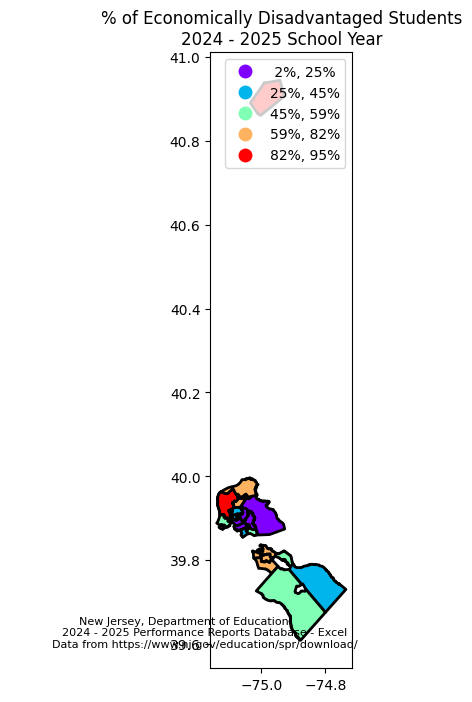

In [140]:
fig, ax = plt.subplots(figsize=(6,8))

# Convert the 'Economically Disadvantaged Students' column to numeric, handling NaN values
a1['Economically Disadvantaged Students'] = a1['Economically Disadvantaged Students'].apply(lambda x: float(x.replace('%', '')) if isinstance(x, str) else x)

a1.plot(ax=ax,figsize=(6,8),column='Economically Disadvantaged Students',legend=True,cmap='rainbow',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}%"})
ax.set_title('''% of Economically Disadvantaged Students
2024 - 2025 School Year''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''New Jersey, Department of Education
            2024 - 2025 Performance Reports Database - Excel
            Data from https://www.nj.gov/education/spr/download/
            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )